# Longitudinal EEG Aging Manifold

Clean, organized Colab notebook for the CADENCE EEG analysis.

This notebook is organized to avoid accidental re-downloads and accidental re-extractions.  
The default behavior is:

1. Mount Google Drive.
2. Load existing downloaded EDF files from `data_full_edf_s3`.
3. Load existing extracted feature CSVs when available.
4. Recompute only missing feature tables.
5. Run the final analysis and regenerate manuscript figures without titles.

Expected runtime if feature CSVs already exist: **2--5 minutes**.  
Expected runtime if baseline and session-2 features must be extracted: **30--40 minutes**.

## 0. Colab setup

Run this first.  
Estimated time: **1 minute**.

In [ ]:
# #from google.colab import drive
# #drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
# Install dependencies only when needed.
# In Colab, run this after a fresh runtime, then restart the runtime if pip asks for it.

import sys
import subprocess

packages = [
    "mne",
    "mne-bids",
    "openneuro-py",
    "pandas",
    "numpy",
    "scipy",
    "scikit-learn",
    "matplotlib",
    "tqdm",
    "awscli",
]

subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "-q"] + packages
)

0

## 1. Project paths and imports

Estimated time: **under 10 seconds**.

In [ ]:
import os
import glob
import time
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from scipy.stats import spearmanr, wilcoxon

from sklearn.model_selection import KFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression

import mne

warnings.filterwarnings("ignore")

# Use local repository relative paths
PROJECT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_DIR = f"{PROJECT_DIR}/data"
FULL_EDF_DIR = f"{PROJECT_DIR}/data_full_edf_s3"
FEATURE_DIR = f"{PROJECT_DIR}/outputs"  # Point to existing local outputs instead of 'features'
FIGURE_DIR = f"{PROJECT_DIR}/manuscript/figures"

for folder in [DATA_DIR, FULL_EDF_DIR, FEATURE_DIR, FIGURE_DIR]:
    os.makedirs(folder, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_DIR:", DATA_DIR)
print("FULL_EDF_DIR:", FULL_EDF_DIR)
print("FEATURE_DIR (Mapped to Outputs):", FEATURE_DIR)
print("FIGURE_DIR:", FIGURE_DIR)
print("MNE:", mne.__version__)


PROJECT_DIR: /content/drive/MyDrive/CADENCE_EEG
DATA_DIR: /content/drive/MyDrive/CADENCE_EEG/data
FULL_EDF_DIR: /content/drive/MyDrive/CADENCE_EEG/data_full_edf_s3
FEATURE_DIR: /content/drive/MyDrive/CADENCE_EEG/features
FIGURE_DIR: /content/drive/MyDrive/CADENCE_EEG/figures
MNE: 1.12.1


## 2. Load participant metadata

This uses the metadata already saved in your project. If `participants.tsv` is missing, the cell downloads only metadata, not EEG.

Estimated time: **under 1 minute**.

In [4]:
participants_path = f"{DATA_DIR}/participants.tsv"

if not os.path.exists(participants_path):
    import openneuro

    print("participants.tsv not found. Downloading metadata only.")
    openneuro.download(
        dataset="ds005385",
        target_dir=DATA_DIR,
        include=["participants.tsv", "dataset_description.json"]
    )

participants = pd.read_csv(participants_path, sep="\t")
participants.to_csv(f"{FEATURE_DIR}/participants_clean.csv", index=False)

print("Participants:", participants.shape)
print("Columns:", participants.columns.tolist())
participants.head()

Participants: (608, 8)
Columns: ['participant_id', 'sex', 'age', 'handedness', 'session1', 'late_ses1', 'session2', 'late_ses2']


,participant_id,sex,age,handedness,session1,late_ses1,session2,late_ses2
0,sub-001,F,60,right,yes,0,yes,0.0
1,sub-002,M,67,right,yes,0,no,NaN
2,sub-003,F,44,right,yes,0,no,NaN
3,sub-004,F,24,right,yes,0,no,NaN
4,sub-005,F,48,right,yes,0,yes,5.0


## 3. Verify local EDF files

This cell does **not** download anything. It only checks what is already in Google Drive.

Expected result after the full S3 sync: **3264 EDF files from 608 subjects**.  
Estimated time: **under 1 minute**.

In [5]:
full_edf_files = sorted(
    glob.glob(f"{FULL_EDF_DIR}/**/*.edf", recursive=True)
)

full_subjects = sorted({
    f.split("/data_full_edf_s3/")[1].split("/")[0]
    for f in full_edf_files
    if "/data_full_edf_s3/sub-" in f
})

print("EDF files:", len(full_edf_files))
print("Subjects:", len(full_subjects))
print("First subjects:", full_subjects[:10])
print("Last subjects:", full_subjects[-10:])

EDF files: 3264
Subjects: 608
First subjects: ['sub-001', 'sub-002', 'sub-003', 'sub-004', 'sub-005', 'sub-006', 'sub-007', 'sub-008', 'sub-009', 'sub-010']
Last subjects: ['sub-599', 'sub-600', 'sub-601', 'sub-602', 'sub-603', 'sub-604', 'sub-605', 'sub-606', 'sub-607', 'sub-608']


## 3A. Optional full EDF download from OpenNeuro S3

Use this only if Cell 3 reports missing EDFs.  
Do **not** run this again if you already have 3264 EDF files.

Estimated time: **variable, often 30--90 minutes**.

In [6]:
import subprocess

RUN_S3_DOWNLOAD = False

if RUN_S3_DOWNLOAD:
    cmd = [
        "aws", "s3", "sync",
        "s3://openneuro.org/ds005385",
        FULL_EDF_DIR,
        "--no-sign-request",
        "--exclude", "*",
        "--include", "sub-*/ses-*/eeg/*_eeg.edf",
    ]
    subprocess.run(cmd, check=True)
else:
    print("S3 download skipped. Set RUN_S3_DOWNLOAD = True only if EDF files are missing.")

S3 download skipped. Set RUN_S3_DOWNLOAD = True only if EDF files are missing.


## 4. Select baseline and follow-up files

Baseline condition: `ses-1`, `task-EyesClosed`, `acq-pre`.  
Follow-up condition: `ses-2`, `task-EyesClosed`, `acq-pre`.

Estimated time: **under 10 seconds**.

In [7]:
baseline_edf_files = [
    f for f in full_edf_files
    if "ses-1" in f
    and "task-EyesClosed" in f
    and "acq-pre" in f
]

ses2_edf_files = [
    f for f in full_edf_files
    if "ses-2" in f
    and "task-EyesClosed" in f
    and "acq-pre" in f
]

print("Baseline EDF files:", len(baseline_edf_files))
print("Session-2 EDF files:", len(ses2_edf_files))

print("\nFirst baseline file:")
print(baseline_edf_files[0] if baseline_edf_files else "none")

print("\nFirst session-2 file:")
print(ses2_edf_files[0] if ses2_edf_files else "none")

Baseline EDF files: 608
Session-2 EDF files: 208

First baseline file:
/content/drive/MyDrive/CADENCE_EEG/data_full_edf_s3/sub-001/ses-1/eeg/sub-001_ses-1_task-EyesClosed_acq-pre_eeg.edf

First session-2 file:
/content/drive/MyDrive/CADENCE_EEG/data_full_edf_s3/sub-001/ses-2/eeg/sub-001_ses-2_task-EyesClosed_acq-pre_eeg.edf


## 5. EEG feature extraction function

This is the final corrected extractor used in the analysis.  
It computes absolute and relative spectral power, alpha sub-bands, beta/alpha ratios, individual alpha frequency, and aperiodic slope.

Estimated time: **under 10 seconds**.

In [8]:
def extract_eeg_features_regional_corrected_from_edf(eeg_file):
    import mne
    import numpy as np
    import os
    import re

    raw = mne.io.read_raw_edf(eeg_file, preload=True, verbose=False)

    raw.pick(picks="eeg")
    raw.resample(250, verbose=False)
    raw.filter(l_freq=1, h_freq=45, verbose=False)
    raw.notch_filter(freqs=[50], verbose=False)
    raw.set_eeg_reference("average", verbose=False)

    spectrum = raw.compute_psd(
        method="welch",
        fmin=1,
        fmax=45,
        n_fft=512,
        n_overlap=256,
        verbose=False
    )

    psds, freqs = spectrum.get_data(return_freqs=True)
    ch_names = raw.ch_names

    bands = {
        "delta": (1, 4),
        "theta": (4, 8),
        "alpha": (8, 13),
        "low_alpha": (8, 10),
        "high_alpha": (10, 13),
        "beta": (13, 30),
        "gamma": (30, 45),
    }

    regions = {
        "frontal": ["Fp1", "Fp2", "F7", "F3", "Fz", "F4", "F8"],
        "central": ["FC5", "FC1", "FC2", "FC6", "C3", "Cz", "C4"],
        "temporal": ["T7", "T8", "TP9", "TP10"],
        "parietal": ["CP5", "CP1", "CP2", "CP6", "P7", "P3", "Pz", "P4", "P8"],
        "occipital": ["O1", "Oz", "O2"],
    }

    features = {}

    total_idx = (freqs >= 1) & (freqs <= 45)
    total_power_global = psds[:, total_idx].sum()

    for band_name, (fmin, fmax) in bands.items():
        f_idx = (freqs >= fmin) & (freqs <= fmax)
        band_power = psds[:, f_idx].sum()

        features[f"global_abs_{band_name}"] = float(band_power)
        features[f"global_rel_{band_name}"] = float(band_power / total_power_global)

    for region_name, region_channels in regions.items():
        ch_idx = [i for i, ch in enumerate(ch_names) if ch in region_channels]

        if len(ch_idx) == 0:
            continue

        region_total_power = psds[ch_idx][:, total_idx].sum()

        for band_name, (fmin, fmax) in bands.items():
            f_idx = (freqs >= fmin) & (freqs <= fmax)
            region_band_power = psds[ch_idx][:, f_idx].sum()

            features[f"{region_name}_abs_{band_name}"] = float(region_band_power)
            features[f"{region_name}_rel_{band_name}"] = float(region_band_power / region_total_power)

    alpha_idx = (freqs >= 8) & (freqs <= 13)

    global_alpha_curve = psds[:, alpha_idx].mean(axis=0)
    features["iaf_global"] = float(freqs[alpha_idx][np.argmax(global_alpha_curve)])

    for region_name in ["parietal", "occipital"]:
        region_channels = regions[region_name]
        ch_idx = [i for i, ch in enumerate(ch_names) if ch in region_channels]

        if len(ch_idx) > 0:
            alpha_curve = psds[ch_idx][:, alpha_idx].mean(axis=0)
            features[f"iaf_{region_name}"] = float(freqs[alpha_idx][np.argmax(alpha_curve)])

    eps = 1e-30

    features["global_theta_alpha_ratio"] = float(
        features["global_abs_theta"] / (features["global_abs_alpha"] + eps)
    )

    features["global_beta_alpha_ratio"] = float(
        features["global_abs_beta"] / (features["global_abs_alpha"] + eps)
    )

    if "occipital_abs_theta" in features and "occipital_abs_alpha" in features:
        features["occipital_theta_alpha_ratio"] = float(
            features["occipital_abs_theta"] / (features["occipital_abs_alpha"] + eps)
        )

    if "parietal_abs_theta" in features and "parietal_abs_alpha" in features:
        features["parietal_theta_alpha_ratio"] = float(
            features["parietal_abs_theta"] / (features["parietal_abs_alpha"] + eps)
        )

    slope_idx = ((freqs >= 2) & (freqs <= 40) & ~((freqs >= 8) & (freqs <= 13)))
    x = np.log10(freqs[slope_idx])
    y = np.log10(psds[:, slope_idx].mean(axis=0) + eps)
    slope, intercept = np.polyfit(x, y, 1)

    features["aperiodic_slope_global"] = float(slope)
    features["aperiodic_intercept_global"] = float(intercept)

    filename = os.path.basename(eeg_file)

    def get_pattern(pattern):
        match = re.search(pattern, filename)
        return match.group(1) if match else None

    features["participant_id"] = get_pattern(r"(sub-[A-Za-z0-9]+)")
    features["session"] = get_pattern(r"(ses-[A-Za-z0-9]+)")
    features["task"] = get_pattern(r"task-([A-Za-z0-9]+)")
    features["acquisition"] = get_pattern(r"acq-([A-Za-z0-9]+)")
    features["eeg_file"] = eeg_file
    features["filename"] = filename

    return features

print("Extractor ready.")

Extractor ready.


## 6. Extract or load baseline and session-2 features

The cell below will **load existing CSVs** if they already exist.  
It extracts features only if a CSV is missing or if `FORCE_REEXTRACT = True`.

Expected time if CSVs exist: **under 1 minute**.  
Expected time if extracting from EDF: baseline **20--25 minutes**, session-2 **8--10 minutes**.

In [9]:
def extract_or_load_features(edf_files, final_path, failures_path, checkpoint_path, label, force=False):
    if os.path.exists(final_path) and not force:
        print(f"{label}: loading existing feature file")
        df = pd.read_csv(final_path)
        print(f"{label}: shape", df.shape)
        return df

    print(f"{label}: extracting features from {len(edf_files)} EDF files")
    start_time = time.time()

    rows = []
    failures = []

    for i, eeg_file in enumerate(tqdm(edf_files), start=1):
        try:
            rows.append(extract_eeg_features_regional_corrected_from_edf(eeg_file))
        except Exception as e:
            failures.append({
                "eeg_file": eeg_file,
                "error": str(e)
            })

        if i % 50 == 0:
            pd.DataFrame(rows).to_csv(checkpoint_path, index=False)

    features_df = pd.DataFrame(rows)
    failures_df = pd.DataFrame(failures)

    if len(features_df) > 0:
        features_merged = features_df.merge(
            participants,
            on="participant_id",
            how="left"
        )
    else:
        features_merged = features_df

    features_merged.to_csv(final_path, index=False)

    if len(failures_df) > 0:
        failures_df.to_csv(failures_path, index=False)

    elapsed = time.time() - start_time

    print(f"{label}: processed", len(features_df))
    print(f"{label}: failures", len(failures_df))
    print(f"{label}: elapsed minutes", round(elapsed / 60, 2))
    print(f"{label}: saved", final_path)

    return features_merged


FORCE_REEXTRACT = False

baseline_features_path = f"{FEATURE_DIR}/baseline_s3_corrected_features.csv"
baseline_features_df = extract_or_load_features(
    edf_files=baseline_edf_files,
    final_path=baseline_features_path,
    failures_path=f"{FEATURE_DIR}/baseline_s3_corrected_failures.csv",
    checkpoint_path=f"{FEATURE_DIR}/baseline_s3_corrected_features_checkpoint.csv",
    label="Baseline ses-1 EyesClosed pre",
    force=FORCE_REEXTRACT
)

ses2_features_path = f"{FEATURE_DIR}/ses2_eyesclosed_pre_features.csv"
ses2_features_df = extract_or_load_features(
    edf_files=ses2_edf_files,
    final_path=ses2_features_path,
    failures_path=f"{FEATURE_DIR}/ses2_eyesclosed_pre_failures.csv",
    checkpoint_path=f"{FEATURE_DIR}/ses2_eyesclosed_pre_checkpoint.csv",
    label="Follow-up ses-2 EyesClosed pre",
    force=FORCE_REEXTRACT
)

Baseline ses-1 EyesClosed pre: loading existing feature file
Baseline ses-1 EyesClosed pre: shape (608, 106)
Follow-up ses-2 EyesClosed pre: loading existing feature file
Follow-up ses-2 EyesClosed pre: shape (208, 106)


## 7. Define feature columns and preprocessing

Metadata are excluded from all predictive models, stability analyses, and figures.

Estimated time: **under 10 seconds**.

In [10]:
baseline_full_df = pd.read_csv(baseline_features_path)
followup_df = pd.read_csv(ses2_features_path)

metadata_cols = [
    "participant_id", "session", "task", "acquisition",
    "eeg_file", "filename", "sex", "handedness",
    "session1", "late_ses1", "session2", "late_ses2",
    "age"
]

numeric_cols = baseline_full_df.select_dtypes(include="number").columns.tolist()

feature_cols_full = [
    c for c in numeric_cols
    if c not in metadata_cols
    and not any(term in c.lower() for term in ["session", "ses", "late"])
]

print("Baseline shape:", baseline_full_df.shape)
print("Follow-up shape:", followup_df.shape)
print("Unique baseline participants:", baseline_full_df["participant_id"].nunique())
print("Feature columns:", len(feature_cols_full))
print("First 10 features:", feature_cols_full[:10])


def transform_features(df, feature_cols, fit_stats=None):
    X = df[feature_cols].copy()

    for col in X.columns:
        if "_abs_" in col:
            X[col] = np.log10(X[col] + 1e-30)

    X = X.replace([np.inf, -np.inf], np.nan)

    if fit_stats is None:
        medians = X.median()
        bounds = {}
        X = X.fillna(medians)

        for col in X.columns:
            lo = X[col].quantile(0.01)
            hi = X[col].quantile(0.99)
            bounds[col] = (lo, hi)
            X[col] = X[col].clip(lo, hi)

        fit_stats = {
            "medians": medians,
            "bounds": bounds
        }
    else:
        X = X.fillna(fit_stats["medians"])

        for col in X.columns:
            lo, hi = fit_stats["bounds"][col]
            X[col] = X[col].clip(lo, hi)

    return X, fit_stats

Baseline shape: (608, 106)
Follow-up shape: (208, 106)
Unique baseline participants: 608
Feature columns: 93
First 10 features: ['global_abs_delta', 'global_rel_delta', 'global_abs_theta', 'global_rel_theta', 'global_abs_alpha', 'global_rel_alpha', 'global_abs_low_alpha', 'global_rel_low_alpha', 'global_abs_high_alpha', 'global_rel_high_alpha']


## 8. Age-associated EEG features

Estimated time: **under 1 minute**.

In [11]:
corr_rows = []

for col in feature_cols_full:
    tmp = baseline_full_df[["age", col]].dropna()

    if tmp[col].nunique() > 1:
        corr_rows.append({
            "feature": col,
            "pearson_r": tmp["age"].corr(tmp[col], method="pearson"),
            "spearman_rho": tmp["age"].corr(tmp[col], method="spearman")
        })

age_corr_full_df = (
    pd.DataFrame(corr_rows)
    .assign(abs_spearman=lambda d: d["spearman_rho"].abs())
    .sort_values("abs_spearman", ascending=False)
)

age_corr_path = f"{FEATURE_DIR}/age_feature_correlations.csv"
age_corr_full_df.to_csv(age_corr_path, index=False)

print("Saved:", age_corr_path)
age_corr_full_df.head(20)

Saved: /content/drive/MyDrive/CADENCE_EEG/features/age_feature_correlations.csv


,feature,pearson_r,spearman_rho,abs_spearman
39,central_rel_beta,0.382427,0.394081,0.394081
78,occipital_abs_high_alpha,-0.001221,-0.368781,0.368781
67,parietal_rel_beta,0.340438,0.349368,0.349368
8,global_abs_high_alpha,-0.008035,-0.327404,0.327404
64,parietal_abs_high_alpha,-0.011390,-0.325774,0.325774
22,frontal_abs_high_alpha,-0.002507,-0.319109,0.319109
70,occipital_abs_delta,0.003809,-0.315314,0.315314
11,global_rel_beta,0.302200,0.312302,0.312302
56,parietal_abs_delta,-0.004993,-0.306181,0.306181
36,central_abs_high_alpha,-0.012200,-0.291184,0.291184


## 9. Brain-age model and bias correction

Estimated time: **1--2 minutes**.

In [12]:
X_full, feature_stats = transform_features(baseline_full_df, feature_cols_full)
y_full = baseline_full_df["age"].copy()

brain_age_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", RidgeCV(alphas=np.logspace(-2, 6, 80)))
])

cv = KFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

pred_age = cross_val_predict(
    brain_age_model,
    X_full,
    y_full,
    cv=cv
)

brain_age_full_df = pd.DataFrame({
    "participant_id": baseline_full_df["participant_id"],
    "sex": baseline_full_df["sex"],
    "true_age": y_full,
    "predicted_age": pred_age
})

brain_age_full_df["brain_age_gap"] = (
    brain_age_full_df["predicted_age"] -
    brain_age_full_df["true_age"]
)

mae = mean_absolute_error(brain_age_full_df["true_age"], brain_age_full_df["predicted_age"])
r = np.corrcoef(brain_age_full_df["true_age"], brain_age_full_df["predicted_age"])[0, 1]
r2 = r2_score(brain_age_full_df["true_age"], brain_age_full_df["predicted_age"])

gap_age_r = np.corrcoef(
    brain_age_full_df["true_age"],
    brain_age_full_df["brain_age_gap"]
)[0, 1]

bias_model = LinearRegression()
bias_model.fit(
    brain_age_full_df[["true_age"]],
    brain_age_full_df["predicted_age"]
)

predicted_from_age = bias_model.predict(
    brain_age_full_df[["true_age"]]
)

brain_age_full_df["predicted_age_corrected"] = (
    brain_age_full_df["predicted_age"] -
    predicted_from_age +
    brain_age_full_df["true_age"]
)

brain_age_full_df["brain_age_gap_corrected"] = (
    brain_age_full_df["predicted_age_corrected"] -
    brain_age_full_df["true_age"]
)

corrected_gap_age_r = np.corrcoef(
    brain_age_full_df["true_age"],
    brain_age_full_df["brain_age_gap_corrected"]
)[0, 1]

brain_age_path = f"{FEATURE_DIR}/brain_age_predictions_full_baseline_corrected.csv"
brain_age_full_df.to_csv(brain_age_path, index=False)

print("N:", len(brain_age_full_df))
print("MAE:", round(mae, 2))
print("Prediction correlation:", round(r, 3))
print("R2:", round(r2, 3))
print("Raw brain-age gap vs age r:", round(gap_age_r, 3))
print("Corrected brain-age gap vs age r:", round(corrected_gap_age_r, 4))
print("Saved:", brain_age_path)

brain_age_full_df.head()

N: 608
MAE: 9.46
Prediction correlation: 0.611
R2: 0.371
Raw brain-age gap vs age r: -0.754
Corrected brain-age gap vs age r: -0.0
Saved: /content/drive/MyDrive/CADENCE_EEG/features/brain_age_predictions_full_baseline_corrected.csv


,participant_id,sex,true_age,predicted_age,brain_age_gap,predicted_age_corrected,brain_age_gap_corrected
0,sub-001,F,60,50.377335,-9.622665,60.076298,0.076298
1,sub-002,M,67,57.936886,-9.063114,71.820705,4.820705
2,sub-003,F,44,45.768114,1.768114,45.901693,1.901693
3,sub-004,F,24,22.103813,-1.896187,10.280662,-13.719338
4,sub-005,F,48,38.770112,-9.229888,41.295037,-6.704963


## 10. PCA latent EEG aging space

Estimated time: **under 1 minute**.

In [13]:
X_cadence = X_full.copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cadence)

pca = PCA(n_components=10, random_state=42)
Z_pca = pca.fit_transform(X_scaled)

pca_cols = [f"PC{i+1}" for i in range(Z_pca.shape[1])]

pca_df = pd.DataFrame(Z_pca, columns=pca_cols)
pca_df["participant_id"] = baseline_full_df["participant_id"].values
pca_df["age"] = baseline_full_df["age"].values
pca_df["sex"] = baseline_full_df["sex"].values

pc_results = []
for pc in pca_cols:
    rho, p = spearmanr(pca_df[pc], pca_df["age"])
    pc_results.append({
        "PC": pc,
        "spearman_rho": rho,
        "pvalue": p
    })

pc_results_df = (
    pd.DataFrame(pc_results)
    .sort_values("spearman_rho", key=np.abs, ascending=False)
)

pca_path = f"{FEATURE_DIR}/pca_latent_trajectory.csv"
pca_df.to_csv(pca_path, index=False)

pc_results_path = f"{FEATURE_DIR}/pca_component_age_correlations.csv"
pc_results_df.to_csv(pc_results_path, index=False)

print("Explained variance ratio:")
for i, v in enumerate(pca.explained_variance_ratio_, start=1):
    print(f"PC{i}: {v:.4f}")
print("Total explained variance:", round(pca.explained_variance_ratio_.sum(), 4))

print("\nTop age-associated PCs:")
print(pc_results_df.head(10))

print("\nSaved:", pca_path)

Explained variance ratio:
PC1: 0.3492
PC2: 0.2270
PC3: 0.1246
PC4: 0.0853
PC5: 0.0463
PC6: 0.0275
PC7: 0.0172
PC8: 0.0137
PC9: 0.0131
PC10: 0.0129
Total explained variance: 0.9168

Top age-associated PCs:
     PC  spearman_rho        pvalue
3   PC4     -0.315716  1.540870e-15
0   PC1     -0.271499  9.824761e-12
5   PC6      0.190356  2.274601e-06
6   PC7     -0.170239  2.444217e-05
1   PC2      0.107214  8.148846e-03
8   PC9     -0.100151  1.348799e-02
7   PC8     -0.092114  2.311906e-02
2   PC3      0.050981  2.093650e-01
4   PC5     -0.021141  6.028728e-01
9  PC10      0.006147  8.797801e-01

Saved: /content/drive/MyDrive/CADENCE_EEG/features/pca_latent_trajectory.csv


## 11. PCA and PLS latent age models

Estimated time: **1--2 minutes**.

In [14]:
# PCA latent age model
X_pca = pca_df[pca_cols]
y = pca_df["age"]

pca_age_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", RidgeCV(alphas=np.logspace(-2, 6, 80)))
])

pca_pred = cross_val_predict(
    pca_age_model,
    X_pca,
    y,
    cv=cv
)

pca_mae = mean_absolute_error(y, pca_pred)
pca_r = np.corrcoef(y, pca_pred)[0, 1]
pca_r2 = r2_score(y, pca_pred)

pca_df["predicted_age_latent"] = pca_pred
pca_df.to_csv(f"{FEATURE_DIR}/pca_latent_trajectory.csv", index=False)

# PLS latent age model
X_pls = X_cadence.copy()
y_pls = baseline_full_df["age"].values

pls = PLSRegression(n_components=5)

y_pred_pls = cross_val_predict(
    pls,
    X_pls,
    y_pls,
    cv=cv
).ravel()

pls_mae = mean_absolute_error(y_pls, y_pred_pls)
pls_r = np.corrcoef(y_pls, y_pred_pls)[0, 1]
pls_r2 = r2_score(y_pls, y_pred_pls)

pls_final = PLSRegression(n_components=5)
pls_final.fit(X_pls, y_pls)

Z_pls = pls_final.transform(X_pls)

pls_cols = [f"PLS{i+1}" for i in range(Z_pls.shape[1])]

pls_df = pd.DataFrame(Z_pls, columns=pls_cols)
pls_df["participant_id"] = baseline_full_df["participant_id"].values
pls_df["age"] = baseline_full_df["age"].values
pls_df["sex"] = baseline_full_df["sex"].values
pls_df["predicted_age_pls"] = y_pred_pls

pls_corr_rows = []
for col in pls_cols:
    rho, p = spearmanr(pls_df[col], pls_df["age"])
    pls_corr_rows.append({
        "component": col,
        "spearman_rho": rho,
        "pvalue": p
    })

pls_corr_df = pd.DataFrame(pls_corr_rows)

pls_path = f"{FEATURE_DIR}/pls_supervised_latent_trajectory.csv"
pls_df.to_csv(pls_path, index=False)

summary_results = pd.DataFrame([
    {
        "model": "Raw EEG Ridge",
        "MAE": mae,
        "correlation": r,
        "R2": r2
    },
    {
        "model": "PLS latent trajectory",
        "MAE": pls_mae,
        "correlation": pls_r,
        "R2": pls_r2
    },
    {
        "model": "PCA latent trajectory",
        "MAE": pca_mae,
        "correlation": pca_r,
        "R2": pca_r2
    },
])

summary_path = f"{FEATURE_DIR}/model_comparison_summary.csv"
summary_results.to_csv(summary_path, index=False)

print("PCA latent age model")
print("MAE:", round(pca_mae, 2), "r:", round(pca_r, 3), "R2:", round(pca_r2, 3))

print("\nPLS latent age model")
print("MAE:", round(pls_mae, 2), "r:", round(pls_r, 3), "R2:", round(pls_r2, 3))

print("\nPLS component correlations")
print(pls_corr_df)

print("\nSaved:", summary_path)
summary_results

PCA latent age model
MAE: 10.71 r: 0.479 R2: 0.23

PLS latent age model
MAE: 10.06 r: 0.538 R2: 0.288

PLS component correlations
  component  spearman_rho        pvalue
0      PLS1      0.376806  6.018141e-22
1      PLS2     -0.332572  3.621113e-17
2      PLS3     -0.167014  3.491188e-05
3      PLS4      0.249024  4.783578e-10
4      PLS5     -0.139347  5.695096e-04

Saved: /content/drive/MyDrive/CADENCE_EEG/features/model_comparison_summary.csv


,model,MAE,correlation,R2
0,Raw EEG Ridge,9.455542,0.610756,0.370603
1,PLS latent trajectory,10.056388,0.538422,0.288139
2,PCA latent trajectory,10.709825,0.479416,0.229827


## 12. CADENCE-style trajectory position and deviation

This defines the PC1--PC4 young-to-old axis, trajectory position, and orthogonal deviation.

Estimated time: **under 1 minute**.

In [15]:
traj_df = pca_df.copy()

pc_x = "PC1"
pc_y = "PC4"

X2 = traj_df[[pc_x, pc_y]].values

young_center = traj_df[
    traj_df["age"] <= traj_df["age"].quantile(0.20)
][[pc_x, pc_y]].mean().values

old_center = traj_df[
    traj_df["age"] >= traj_df["age"].quantile(0.80)
][[pc_x, pc_y]].mean().values

direction = old_center - young_center
direction = direction / np.linalg.norm(direction)

traj_df["trajectory_position"] = (X2 - young_center) @ direction

projection_points = young_center + np.outer(
    traj_df["trajectory_position"],
    direction
)

orthogonal_vectors = X2 - projection_points

traj_df["trajectory_deviation"] = np.linalg.norm(
    orthogonal_vectors,
    axis=1
)

rho_pos, p_pos = spearmanr(
    traj_df["trajectory_position"],
    traj_df["age"]
)

rho_dev, p_dev = spearmanr(
    traj_df["trajectory_deviation"],
    traj_df["age"]
)

traj_out = f"{FEATURE_DIR}/cadence_position_deviation.csv"
traj_df.to_csv(traj_out, index=False)

cadence_summary_df = pd.DataFrame([
    {
        "analysis": "PCA trajectory position",
        "metric": "Spearman rho with age",
        "value": rho_pos,
        "pvalue": p_pos
    },
    {
        "analysis": "PCA trajectory deviation",
        "metric": "Spearman rho with age",
        "value": rho_dev,
        "pvalue": p_dev
    },
    {
        "analysis": "PCA latent age model",
        "metric": "MAE",
        "value": pca_mae,
        "pvalue": np.nan
    },
    {
        "analysis": "PCA latent age model",
        "metric": "correlation",
        "value": pca_r,
        "pvalue": np.nan
    },
    {
        "analysis": "PCA latent age model",
        "metric": "R2",
        "value": pca_r2,
        "pvalue": np.nan
    },
    {
        "analysis": "PLS latent age model",
        "metric": "MAE",
        "value": pls_mae,
        "pvalue": np.nan
    },
    {
        "analysis": "PLS latent age model",
        "metric": "correlation",
        "value": pls_r,
        "pvalue": np.nan
    },
    {
        "analysis": "PLS latent age model",
        "metric": "R2",
        "value": pls_r2,
        "pvalue": np.nan
    },
])

cadence_summary_path = f"{FEATURE_DIR}/cadence_summary_results.csv"
cadence_summary_df.to_csv(cadence_summary_path, index=False)

print("Trajectory position vs age rho:", round(rho_pos, 3))
print("Trajectory position vs age p:", p_pos)
print("Trajectory deviation vs age rho:", round(rho_dev, 3))
print("Trajectory deviation vs age p:", p_dev)
print("\nSaved:", traj_out)
cadence_summary_df

Trajectory position vs age rho: 0.344
Trajectory position vs age p: 2.727908448030402e-18
Trajectory deviation vs age rho: -0.053
Trajectory deviation vs age p: 0.19020443858572988

Saved: /content/drive/MyDrive/CADENCE_EEG/features/cadence_position_deviation.csv


,analysis,metric,value,pvalue
0,PCA trajectory position,Spearman rho with age,0.343613,2.727908e-18
1,PCA trajectory deviation,Spearman rho with age,-0.053198,1.902044e-01
2,PCA latent age model,MAE,10.709825,NaN
3,PCA latent age model,correlation,0.479416,NaN
4,PCA latent age model,R2,0.229827,NaN
5,PLS latent age model,MAE,10.056388,NaN
6,PLS latent age model,correlation,0.538422,NaN
7,PLS latent age model,R2,0.288139,NaN


## 13. Test--retest stability

Metadata variables are explicitly excluded.

Estimated time: **under 1 minute**.

In [16]:
common_subjects = sorted(
    set(baseline_full_df["participant_id"]) &
    set(followup_df["participant_id"])
)

base = baseline_full_df[
    baseline_full_df["participant_id"].isin(common_subjects)
].copy()

fu = followup_df[
    followup_df["participant_id"].isin(common_subjects)
].copy()

base = base.sort_values("participant_id").reset_index(drop=True)
fu = fu.sort_values("participant_id").reset_index(drop=True)

stability_rows = []

for col in feature_cols_full:
    if col in base.columns and col in fu.columns:
        rho, p = spearmanr(base[col], fu[col])
        stability_rows.append({
            "feature": col,
            "test_retest_rho": rho,
            "pvalue": p
        })

stability_df = (
    pd.DataFrame(stability_rows)
    .sort_values("test_retest_rho", ascending=False)
)

stability_path = f"{FEATURE_DIR}/test_retest_stability.csv"
stability_df.to_csv(stability_path, index=False)

print("Common longitudinal subjects:", len(common_subjects))
print("Mean test-retest rho:", stability_df["test_retest_rho"].mean())
print("Saved:", stability_path)
stability_df.head(20)

Common longitudinal subjects: 208
Mean test-retest rho: 0.6923108336839492
Saved: /content/drive/MyDrive/CADENCE_EEG/features/test_retest_stability.csv


,feature,test_retest_rho,pvalue
88,global_beta_alpha_ratio,0.893671,1.259303e-73
75,occipital_rel_alpha,0.859092,7.729476e-62
77,occipital_rel_low_alpha,0.842495,2.994479e-57
74,occipital_abs_alpha,0.836615,9.456930e-56
61,parietal_rel_alpha,0.831389,1.817123e-54
63,parietal_rel_low_alpha,0.830221,3.469684e-54
4,global_abs_alpha,0.829617,4.838529e-54
8,global_abs_high_alpha,0.824679,6.988391e-53
21,frontal_rel_low_alpha,0.824275,8.662739e-53
78,occipital_abs_high_alpha,0.822168,2.631563e-52


## 14. Longitudinal CADENCE shift

This projects session-2 recordings into the baseline PCA space and tests movement along the baseline-defined aging axis.

Estimated time: **1--2 minutes**.

In [17]:
X_base, base_stats = transform_features(base, feature_cols_full)
X_fu, _ = transform_features(fu, feature_cols_full, fit_stats=base_stats)

X_base_scaled = scaler.transform(X_base)
X_fu_scaled = scaler.transform(X_fu)

Z_base = pca.transform(X_base_scaled)
Z_fu = pca.transform(X_fu_scaled)

base_latent = pd.DataFrame(Z_base, columns=[f"base_{c}" for c in pca_cols])
fu_latent = pd.DataFrame(Z_fu, columns=[f"fu_{c}" for c in pca_cols])

long_df = pd.concat(
    [
        base[["participant_id", "age", "sex", "late_ses2"]].reset_index(drop=True),
        base_latent,
        fu_latent
    ],
    axis=1
)

base_X2 = long_df[["base_PC1", "base_PC4"]].values
fu_X2 = long_df[["fu_PC1", "fu_PC4"]].values

long_df["base_trajectory_position"] = (base_X2 - young_center) @ direction
long_df["fu_trajectory_position"] = (fu_X2 - young_center) @ direction

long_df["delta_trajectory_position"] = (
    long_df["fu_trajectory_position"] -
    long_df["base_trajectory_position"]
)

projection_base = young_center + np.outer(
    long_df["base_trajectory_position"],
    direction
)

projection_fu = young_center + np.outer(
    long_df["fu_trajectory_position"],
    direction
)

long_df["base_trajectory_deviation"] = np.linalg.norm(
    base_X2 - projection_base,
    axis=1
)

long_df["fu_trajectory_deviation"] = np.linalg.norm(
    fu_X2 - projection_fu,
    axis=1
)

long_df["delta_trajectory_deviation"] = (
    long_df["fu_trajectory_deviation"] -
    long_df["base_trajectory_deviation"]
)

w_pos = wilcoxon(long_df["delta_trajectory_position"])
w_dev = wilcoxon(long_df["delta_trajectory_deviation"])

rho_base_future, p_base_future = spearmanr(
    long_df["base_trajectory_position"],
    long_df["delta_trajectory_position"]
)

rho_age_future, p_age_future = spearmanr(
    long_df["age"],
    long_df["delta_trajectory_position"]
)

long_path = f"{FEATURE_DIR}/longitudinal_cadence_shift.csv"
long_df.to_csv(long_path, index=False)

longitudinal_summary = pd.DataFrame([
    {
        "analysis": "Longitudinal trajectory position shift",
        "n": len(long_df),
        "mean_delta": long_df["delta_trajectory_position"].mean(),
        "median_delta": long_df["delta_trajectory_position"].median(),
        "std_delta": long_df["delta_trajectory_position"].std(),
        "wilcoxon_p": w_pos.pvalue
    },
    {
        "analysis": "Longitudinal trajectory deviation shift",
        "n": len(long_df),
        "mean_delta": long_df["delta_trajectory_deviation"].mean(),
        "median_delta": long_df["delta_trajectory_deviation"].median(),
        "std_delta": long_df["delta_trajectory_deviation"].std(),
        "wilcoxon_p": w_dev.pvalue
    },
    {
        "analysis": "Baseline position vs future trajectory change",
        "n": len(long_df),
        "mean_delta": np.nan,
        "median_delta": np.nan,
        "std_delta": np.nan,
        "wilcoxon_p": np.nan,
        "spearman_rho": rho_base_future,
        "spearman_p": p_base_future
    },
    {
        "analysis": "Chronological age vs future trajectory change",
        "n": len(long_df),
        "mean_delta": np.nan,
        "median_delta": np.nan,
        "std_delta": np.nan,
        "wilcoxon_p": np.nan,
        "spearman_rho": rho_age_future,
        "spearman_p": p_age_future
    },
])

long_summary_path = f"{FEATURE_DIR}/longitudinal_cadence_summary_clean.csv"
longitudinal_summary.to_csv(long_summary_path, index=False)

print("LONGITUDINAL CADENCE SUMMARY")
print("N:", len(long_df))
print("Delta trajectory position mean:", long_df["delta_trajectory_position"].mean())
print("Delta trajectory position median:", long_df["delta_trajectory_position"].median())
print("Delta trajectory position Wilcoxon p:", w_pos.pvalue)
print("Delta trajectory deviation Wilcoxon p:", w_dev.pvalue)
print("Baseline position vs future change rho:", rho_base_future, "p:", p_base_future)
print("Age vs future change rho:", rho_age_future, "p:", p_age_future)
print("\nSaved:", long_path)
longitudinal_summary

LONGITUDINAL CADENCE SUMMARY
N: 208
Delta trajectory position mean: 0.40272577532450565
Delta trajectory position median: 0.5223248266037555
Delta trajectory position Wilcoxon p: 0.002021062607726091
Delta trajectory deviation Wilcoxon p: 0.6215767191709265
Baseline position vs future change rho: -0.2803950435529383 p: 4.093494599919161e-05
Age vs future change rho: -0.018083036634951425 p: 0.7954448072848598

Saved: /content/drive/MyDrive/CADENCE_EEG/features/longitudinal_cadence_shift.csv


,analysis,n,mean_delta,median_delta,std_delta,wilcoxon_p,spearman_rho,spearman_p
0,Longitudinal trajectory position shift,208,0.402726,0.522325,3.178133,0.002021,NaN,NaN
1,Longitudinal trajectory deviation shift,208,0.058976,0.161201,1.456253,0.621577,NaN,NaN
2,Baseline position vs future trajectory change,208,NaN,NaN,NaN,NaN,-0.280395,0.000041
3,Chronological age vs future trajectory change,208,NaN,NaN,NaN,NaN,-0.018083,0.795445


## 15. Generate manuscript figures without titles

The stability figure excludes metadata variables.  
The filenames match the LaTeX manuscript.

Estimated time: **1--2 minutes**.

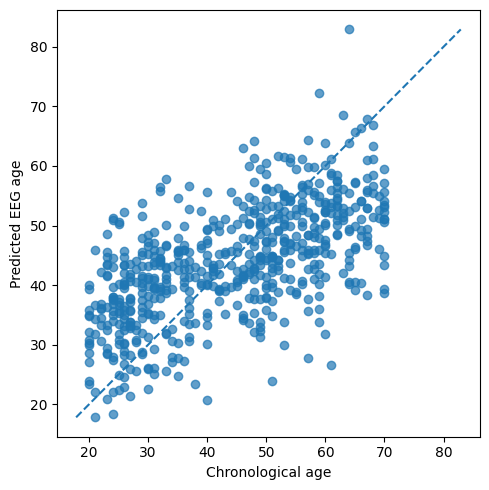

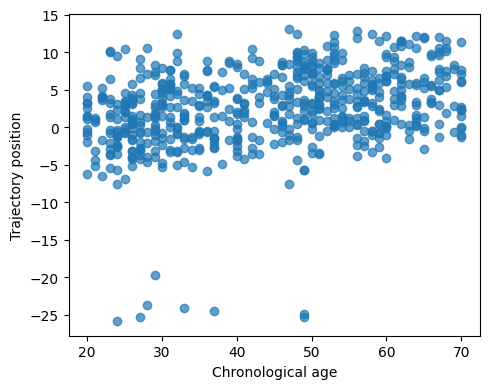

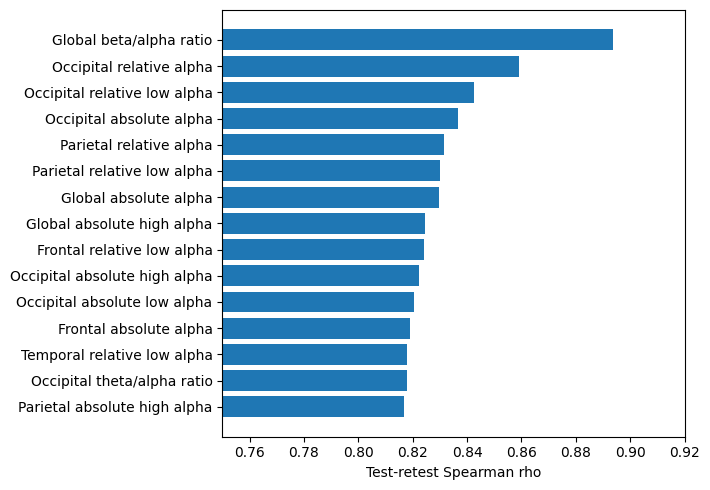

Figure 3 features:
                        feature                  display_label  \
88      global_beta_alpha_ratio        Global beta/alpha ratio   
75          occipital_rel_alpha       Occipital relative alpha   
77      occipital_rel_low_alpha   Occipital relative low alpha   
74          occipital_abs_alpha       Occipital absolute alpha   
61           parietal_rel_alpha        Parietal relative alpha   
63       parietal_rel_low_alpha    Parietal relative low alpha   
4              global_abs_alpha          Global absolute alpha   
8         global_abs_high_alpha     Global absolute high alpha   
21        frontal_rel_low_alpha     Frontal relative low alpha   
78     occipital_abs_high_alpha  Occipital absolute high alpha   
76      occipital_abs_low_alpha   Occipital absolute low alpha   
18            frontal_abs_alpha         Frontal absolute alpha   
49       temporal_rel_low_alpha    Temporal relative low alpha   
89  occipital_theta_alpha_ratio    Occipital theta/alpha 

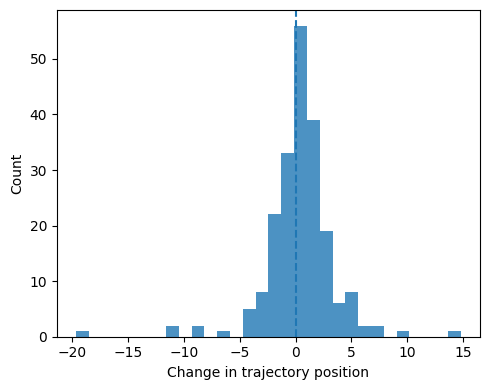

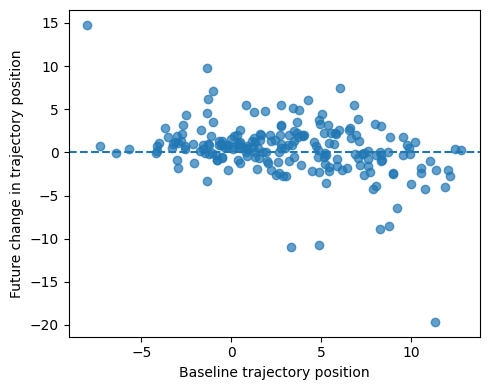

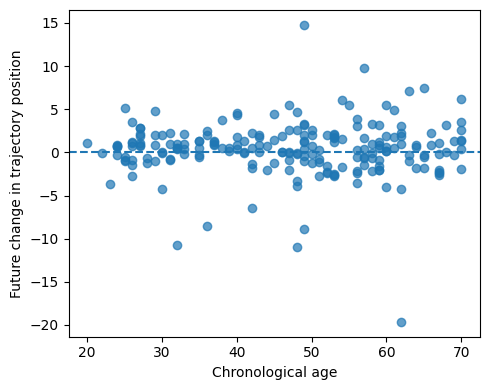

Saved figures to: /content/drive/MyDrive/CADENCE_EEG/figures


In [21]:
# =====================================================
# Figure 3: test-retest stability
# =====================================================

import matplotlib.patches as mpatches
import numpy as np

def prettify_feature_label(name):
    label = str(name)

    # Ratios first, before generic replacements
    label = label.replace('global_beta_alpha_ratio', 'Global | beta/alpha ratio')
    label = label.replace('occipital_theta_alpha_ratio', 'Occipital | theta/alpha ratio')
    label = label.replace('parietal_theta_alpha_ratio', 'Parietal | theta/alpha ratio')
    label = label.replace('global_theta_alpha_ratio', 'Global | theta/alpha ratio')
    label = label.replace('occipital_beta_alpha_ratio', 'Occipital | beta/alpha ratio')
    label = label.replace('parietal_beta_alpha_ratio', 'Parietal | beta/alpha ratio')

    # Region names
    label = label.replace('global_', 'Global | ')
    label = label.replace('frontal_', 'Frontal | ')
    label = label.replace('central_', 'Central | ')
    label = label.replace('parietal_', 'Parietal | ')
    label = label.replace('temporal_', 'Temporal | ')
    label = label.replace('occipital_', 'Occipital | ')

    # Power type
    label = label.replace('abs_', 'absolute ')
    label = label.replace('rel_', 'relative ')

    # Bands
    label = label.replace('high_alpha', 'high alpha')
    label = label.replace('low_alpha', 'low alpha')

    # Clean remaining underscores
    label = label.replace('_', ' ')
    label = ' '.join(label.split())

    return label[0].upper() + label[1:] if label else label

def categorize_feature(name):
    if 'ratio' in name:
        return 'Ratio'
    elif 'alpha' in name:
        return 'Alpha'
    elif 'beta' in name:
        return 'Beta'
    elif 'theta' in name:
        return 'Theta'
    elif 'delta' in name:
        return 'Delta'
    else:
        return 'Other'

exclude_terms = [
    'age', 'sex', 'session', 'ses', 'late', 'participant',
    'filename', 'file', 'handedness', 'task', 'acquisition'
]

stability_plot_df = stability_df[
    ~stability_df['feature'].str.contains(
        '|'.join(exclude_terms),
        case=False,
        regex=True,
        na=False
    )
].copy()

top_stability = (
    stability_plot_df
    .sort_values('test_retest_rho', ascending=False)
    .head(15)
    .copy()
)

top_stability['display_label'] = top_stability['feature'].apply(prettify_feature_label)
top_stability['category'] = top_stability['feature'].apply(categorize_feature)

# Colors for categories
color_map = {
    'Ratio': '#D55E00',     # Vermilion
    'Alpha': '#0072B2',     # Blue
    'Beta': '#009E73',      # Green
    'Theta': '#CC79A7',     # Reddish purple
    'Delta': '#F0E442',     # Yellow
    'Other': '#999999'      # Grey
}
top_stability['color'] = top_stability['category'].map(lambda x: color_map.get(x, '#999999'))

# Reverse order for plotting top-down
plot_labels = top_stability['display_label'][::-1].tolist()
plot_vals = top_stability['test_retest_rho'][::-1].tolist()
plot_colors = top_stability['color'][::-1].tolist()

fig, ax = plt.subplots(figsize=(8.5, 6))

bars = ax.barh(plot_labels, plot_vals, color=plot_colors, edgecolor='none', height=0.7)

# Add values at the end of each bar
for bar, val in zip(bars, plot_vals):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
            va='center', ha='left', fontsize=9, color='black')

ax.set_xlabel('Test-retest Spearman rho', fontsize=11, fontweight='bold')
ax.set_ylabel('')
ax.set_xlim(0.70, 0.95)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='y', labelsize=10)

# Add legend
legend_handles = [mpatches.Patch(color=color_map[cat], label=cat) for cat in top_stability['category'].unique()]
ax.legend(handles=legend_handles, title='Feature Category', loc='lower right', frameon=False)

# Add summary annotation
ax.text(0.02, 0.98, 'Ratio-based and occipital alpha features\nshow the highest test–retest stability.',
        transform=ax.transAxes, fontsize=11, va='top', ha='left',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig3_test_retest_stability.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{FIGURE_DIR}/fig3_test_retest_stability.pdf', bbox_inches='tight')
plt.show()

print('Figure 3 features:')
print(top_stability[['feature', 'display_label', 'test_retest_rho', 'category']])


## 16. Final result checklist

This cell prints the key manuscript values.

Estimated time: **under 10 seconds**.

In [19]:
print("BASELINE AGE MODEL")
print("N:", len(brain_age_full_df))
print("MAE:", round(mae, 2))
print("Prediction correlation:", round(r, 3))
print("R2:", round(r2, 3))

print("\nPCA TRAJECTORY")
print("Trajectory position vs age rho:", round(rho_pos, 3))
print("Trajectory position vs age p:", p_pos)
print("Trajectory deviation vs age rho:", round(rho_dev, 3))
print("Trajectory deviation vs age p:", p_dev)

print("\nTEST-RETEST")
print("N longitudinal:", len(common_subjects))
print("Mean test-retest rho:", round(stability_df["test_retest_rho"].mean(), 3))

print("\nLONGITUDINAL SHIFT")
print("Mean delta trajectory position:", round(long_df["delta_trajectory_position"].mean(), 3))
print("Median delta trajectory position:", round(long_df["delta_trajectory_position"].median(), 3))
print("Trajectory position Wilcoxon p:", w_pos.pvalue)
print("Trajectory deviation Wilcoxon p:", w_dev.pvalue)

print("\nDYNAMICS")
print("Baseline position vs future change rho:", round(rho_base_future, 3))
print("Baseline position vs future change p:", p_base_future)
print("Chronological age vs future change rho:", round(rho_age_future, 3))
print("Chronological age vs future change p:", p_age_future)

BASELINE AGE MODEL
N: 608
MAE: 9.46
Prediction correlation: 0.611
R2: 0.371

PCA TRAJECTORY
Trajectory position vs age rho: 0.344
Trajectory position vs age p: 2.727908448030402e-18
Trajectory deviation vs age rho: -0.053
Trajectory deviation vs age p: 0.19020443858572988

TEST-RETEST
N longitudinal: 208
Mean test-retest rho: 0.692

LONGITUDINAL SHIFT
Mean delta trajectory position: 0.403
Median delta trajectory position: 0.522
Trajectory position Wilcoxon p: 0.002021062607726091
Trajectory deviation Wilcoxon p: 0.6215767191709265

DYNAMICS
Baseline position vs future change rho: -0.28
Baseline position vs future change p: 4.093494599919161e-05
Chronological age vs future change rho: -0.018
Chronological age vs future change p: 0.7954448072848598
